In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df=pd.read_csv("/content/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
df.shape

(891, 12)

In [14]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [15]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [16]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


<Axes: xlabel='Sex'>

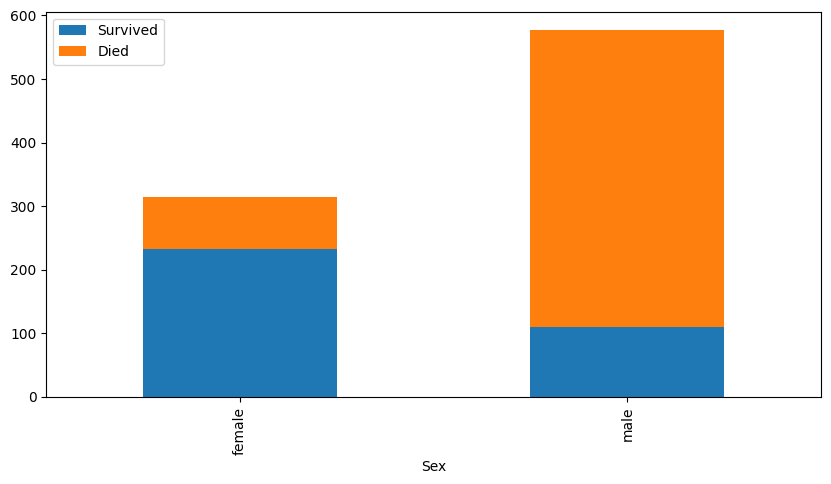

In [17]:
#Visualizing survivals based on gender
df['Died']= 1-df['Survived']
df.groupby('Sex').agg('sum')[['Survived','Died']].plot(kind='bar',figsize=(10,5),stacked=True)

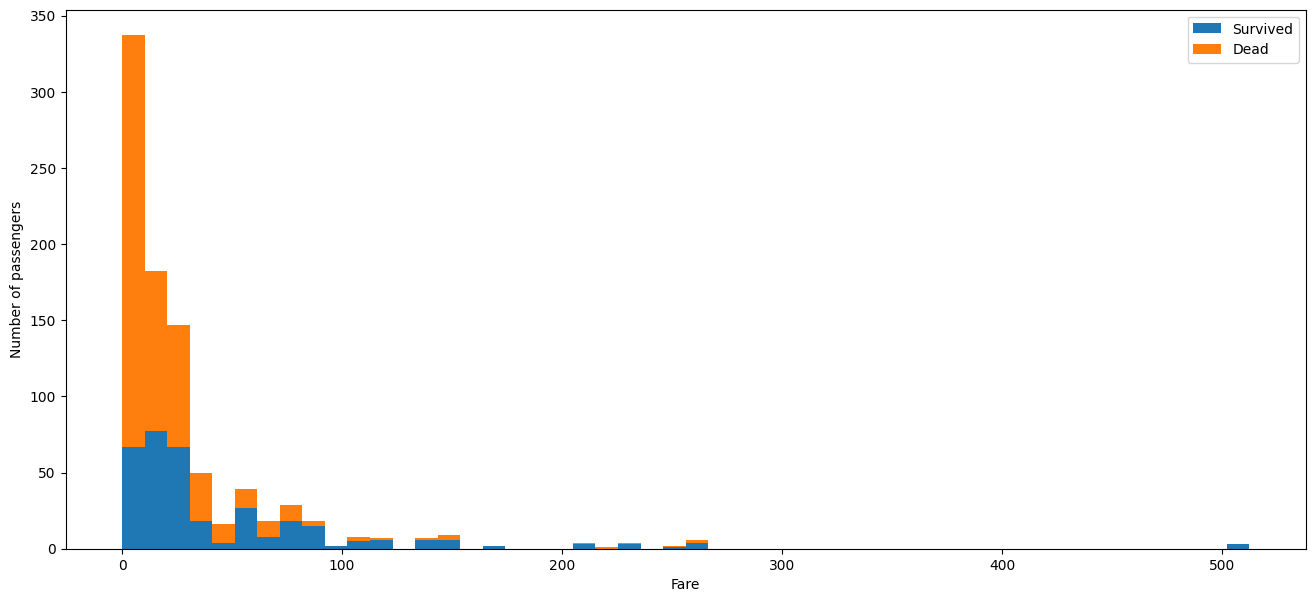

In [19]:
#Visualizing survivals based on fare
figure=plt.figure(figsize=(16,7))
plt.hist([df[df['Survived']==1]['Fare'],df[df['Survived']==0]['Fare']],stacked=True,bins=50,label=['Survived','Dead'])
plt.xlabel("Fare")
plt.ylabel('Number of passengers')
plt.legend()

In [20]:
#Converting the categorical features 'sex' and 'embarked' into numerical
df.replace({'Sex':{'male':0,'female':1}},inplace=True)
df.replace({'Embarked':{'S':0,'C':1,'Q':2}},inplace=True)
df.head(10)

/tmp/ipykernel_2375/2134655895.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Sex':{'male':0,'female':1}},inplace=True)
/tmp/ipykernel_2375/2134655895.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Embarked':{'S':0,'C':1,'Q':2}},inplace=True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Died
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0.0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1.0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0.0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0.0,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0.0,1
5,6,0,3,"Moran, Mr. James",0,NaN,0,0,330877,8.4583,NaN,2.0,1
6,7,0,1,"McCarthy, Mr. Timothy J",0,54.0,0,0,17463,51.8625,E46,0.0,1
7,8,0,3,"Palsson, Master. Gosta Leonard",0,2.0,3,1,349909,21.0750,NaN,0.0,1
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",1,27.0,0,2,347742,11.1333,NaN,0.0,0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",1,14.0,1,0,237736,30.0708,NaN,1.0,0


In [21]:
mean_age_m=df[df['Sex']==0]['Age'].mean()
mean_age_f=df[df['Sex']==1]['Age'].mean()

In [22]:
#Fill all the missing values in age column based on gender
df.loc[(df['Age'].isnull())&(df['Sex']==0),'Age']=mean_age_m
df.loc[(df['Age'].isnull())&(df['Sex']==1),'Age']=mean_age_f

In [23]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [24]:
#Remove irrelevant columns
df2=df.drop(['Name','Ticket','Cabin'],axis=1)
df2.head(10)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Died
0,1,0,3,0,22.000000,1,0,7.2500,0.0,1
1,2,1,1,1,38.000000,1,0,71.2833,1.0,0
2,3,1,3,1,26.000000,0,0,7.9250,0.0,0
3,4,1,1,1,35.000000,1,0,53.1000,0.0,0
4,5,0,3,0,35.000000,0,0,8.0500,0.0,1
5,6,0,3,0,30.726645,0,0,8.4583,2.0,1
6,7,0,1,0,54.000000,0,0,51.8625,0.0,1
7,8,0,3,0,2.000000,3,1,21.0750,0.0,1
8,9,1,3,1,27.000000,0,2,11.1333,0.0,0
9,10,1,2,1,14.000000,1,0,30.0708,1.0,0


In [25]:
df2.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,2
Died,0


In [27]:
df = df.dropna(subset=["Embarked"])

In [28]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
